<h2 style='color:blue' align='center'>Transfer learning in image classification</h2>

**In this notebook we will use transfer learning and take pre-trained model from google's Tensorflow Hub and re-train that on flowers dataset. Using pre-trained model saves lot of time and computational budget for new classification problem at hand**

##### Till Feature vector folder trained Pretrained model  - we need only the feature engineering portion
- https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

##### Complete Pretrained model, which is taken from classification folder
- https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4

In [1]:
#pip install tensorflow_hub

In [2]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

## 1. Make predictions using ready made model (without any training)

## Download Pretrained Model

In [3]:
IMAGE_SHAPE = (224, 224) # this is as per given in tensorflow hub

# Here we are defining our predefined model
classifier = tf.keras.Sequential([
    hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4", input_shape=IMAGE_SHAPE+(3,))
])  # Here this link downloads pretrained model inside our sequential model

# pls refer to ImageNetLabels.txt to see the 1000 classes on which this model is pretrained. This txt we got from
# hub website. This contains all different classes, not only fishes

In [4]:
IMAGE_SHAPE+(3,)  # This adds shape with 3 --> (224, 224, 3)

(224, 224, 3)

## Use sample Gold Fish Image as test sample and use predict option on Pretrained Model

(576, 576, 3)


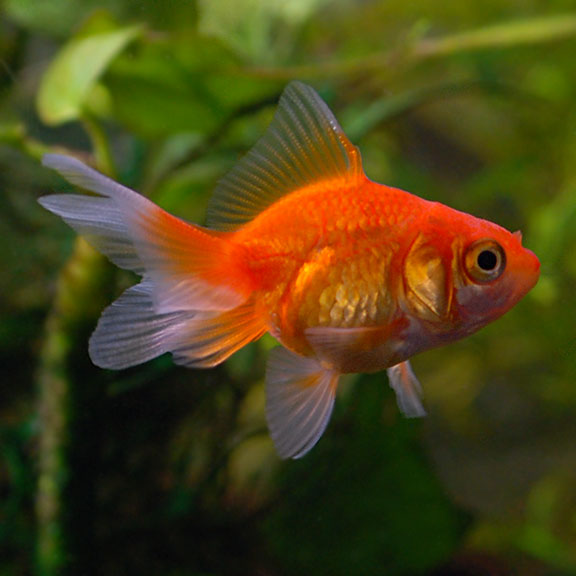

In [33]:
# Original Image
print(np.array(Image.open("goldfish.jpg")).shape)
Image.open("goldfish.jpg")
# Here shape is (576, 576, 3), we need to resize the image

In [34]:
gold_fish = Image.open("goldfish.jpg").resize(IMAGE_SHAPE) # we have only kept this image in current folder. 

In [35]:
gold_fish = np.array(gold_fish)/255.0
gold_fish.shape

(224, 224, 3)

In [36]:
gold_fish[np.newaxis, ...].shape  

# we have put 3 dots to add one more dimension i.e 1 below. This is because when we do prediction we don;t pass
# 1 image we pass many images to accomodate that we change it to 4 dimensions. 

(1, 224, 224, 3)

In [37]:
gold_fish[np.newaxis, ...]

array([[[[0.28235294, 0.33333333, 0.07058824],
         [0.31372549, 0.37254902, 0.09019608],
         [0.34901961, 0.41960784, 0.11764706],
         ...,
         [0.32941176, 0.39215686, 0.00392157],
         [0.32156863, 0.38431373, 0.00392157],
         [0.30980392, 0.36862745, 0.        ]],

        [[0.28627451, 0.33333333, 0.08235294],
         [0.3254902 , 0.38039216, 0.10980392],
         [0.35294118, 0.42352941, 0.12941176],
         ...,
         [0.32156863, 0.38039216, 0.00392157],
         [0.31372549, 0.37254902, 0.00392157],
         [0.30196078, 0.36078431, 0.        ]],

        [[0.28627451, 0.33333333, 0.08627451],
         [0.31372549, 0.36862745, 0.10196078],
         [0.34509804, 0.41568627, 0.12941176],
         ...,
         [0.31764706, 0.37647059, 0.00392157],
         [0.30980392, 0.36862745, 0.00784314],
         [0.29803922, 0.35686275, 0.00392157]],

        ...,

        [[0.05490196, 0.10980392, 0.01568627],
         [0.05098039, 0.11372549, 0.01960784]

## Predict 1 sample image in Pretrained Model

In [38]:
# This is the predicted output, which is array of 1000 values. which is the highest probaibilty is yhe final one, using argmax we will see high index
result = classifier.predict(gold_fish[np.newaxis, ...])
result.shape

(1, 1001)

In [39]:
result

array([[ 0.2210783 ,  2.0497668 ,  9.622809  , ..., -1.4619296 ,
        -0.2823091 , -0.25916258]], dtype=float32)

In [30]:
predicted_label_index = np.argmax(result)
predicted_label_index  

# here we don't know 2 belongs to which class. Manually we need to open the 'ImageNetLabels.txt' and check, 
# instead lets load the 1000 classes into a List and then check.

2

In [31]:
# tf.keras.utils.get_file('ImageNetLabels.txt','https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt')

image_labels = []

with open("ImageNetLabels.txt", "r") as f:
    image_labels = f.read().splitlines()
image_labels[:5]

# we just loaded those 1000 classes into a List. This is required to see if our prediction is correct or not. 

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [32]:
image_labels[predicted_label_index]  # so model predicted it as goldfish.

'goldfish'

## 2.  Load flowers dataset to check Prediction in Pretrained Model

<h3 style='color:purple'>Load flowers dataset</h3>

In [49]:
import PIL

In [ ]:
# below most of the steps we have executed in data_augmentation tutorial, it takes time, so just understanding now
# not going to execute. 

In [50]:
# this is Google path
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

#data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir="/Users/yogesh/Documents/Bharadwaj's/Career/Data Science/Datasets", untar=True)

data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir="Users\prabh\DS Project Toolkit\DL\17_data_augmentation", untar=True)

# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

In [51]:
data_dir

'/tmp\\.keras\\datasets\\flower_photos'

In [52]:
import pathlib
# This pathlib helpful to read all these images as Numby array. This will be same as original path just will be windows path

data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('/tmp/.keras/datasets/flower_photos')

In [53]:
list(data_dir.glob('*/*.jpg'))[:5] # glob gives 1st 5 images which has extension .jpg

[WindowsPath('/tmp/.keras/datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [44]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)
# this is image count

3670


In [47]:
roses = list(data_dir.glob('roses/*'))
roses[:5]
# sample flowers in rose folder

[WindowsPath('/tmp/.keras/datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

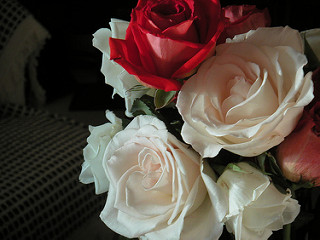

In [54]:
PIL.Image.open(str(roses[1]))
#2nd Image in rose folder

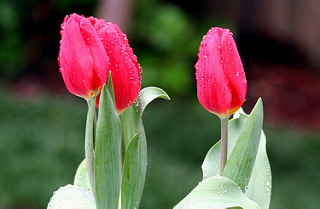

In [55]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

<h3 style='color:purple'>Read flowers images from disk into numpy array using opencv</h3>

In [56]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [57]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [58]:
flowers_images_dict['roses'][:5]

[WindowsPath('/tmp/.keras/datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [59]:
str(flowers_images_dict['roses'][0])

'\\tmp\\.keras\\datasets\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [60]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [61]:
img.shape

(240, 179, 3)

In [62]:
cv2.resize(img,(224,224)).shape

(224, 224, 3)

In [63]:
X, y = [], []

# Here we are labeling each image based on its folder/key value from dictionary "flowers_images_dict"
# Then we are resizing each image into (180,180) and appending each image to X variable and each label to y

for flower_name, images in flowers_images_dict.items():
    # print(images)
    # Here we are reading each flower from each folder one by one: Here flower_name is hardcoded key value in dict
    # Here images is 1 folder all images
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        X.append(resized_img)
         # Here we are appending foldername which are saved as integer value as class/Lable value
        y.append(flowers_labels_dict[flower_name])

In [64]:
X = np.array(X)
y = np.array(y)

<h3 style='color:purple'>Train test split</h3>

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

<h3 style='color:purple'>Preprocessing: scale images</h3>

In [66]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

**Make prediction using pre-trained model on new flowers dataset**

In [67]:
X[0].shape

(224, 224, 3)

In [68]:
IMAGE_SHAPE+(3,)  # IMAGE_SHAPE , we have defined it to 224,244 at the beginning of this notebook.

(224, 224, 3)

In [69]:
# Here we resize images to IMAGE_SHAPE, which is the shape required for pre trained model

x0_resized = cv2.resize(X[0], IMAGE_SHAPE)
x1_resized = cv2.resize(X[1], IMAGE_SHAPE)
x2_resized = cv2.resize(X[2], IMAGE_SHAPE)

In [106]:
print(y[0])
print(y[1])
print(y[2])

0
0
0


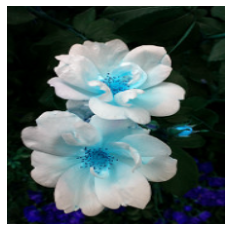

In [70]:
plt.axis('off')
plt.imshow(X[0])

In [78]:
# As per flowers_labels_dict 0 means Rose
"""
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}
"""
print(y[0])

0


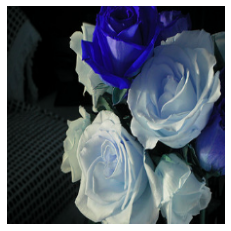

In [79]:
plt.axis('off')
plt.imshow(X[1])

In [80]:
print(y[1])

0


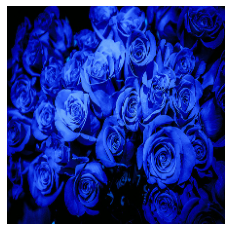

In [81]:
plt.axis('off')
plt.imshow(X[2])

## Predict Flower dataset sample image in Pretrained Model

In [83]:
# below is a pretrained model which we imported above. 

predicted = classifier.predict(np.array([x0_resized, x1_resized, x2_resized]))
predicted = np.argmax(predicted, axis=1)
predicted

array([795, 880, 795], dtype=int64)

In [87]:
print(image_labels[795],'\n' ,image_labels[880], '\n' ,image_labels[795])

shower curtain 
 umbrella 
 shower curtain


> Here actual sample Flowe images are of "Rose" but here pretrained model predicted all 3 differntly instead of Rose

> So we need to freeze few layers in pretrained model and need to use for flower prediction

## 3. RETRAN THE PRETRAIN MODEL:  Load flowers dataset to check Prediction in Retrained - Pretrained Model

<h3 style='color:purple'>Now take pre-trained model and retrain it using flowers images</h3>

In [90]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
# Here we are using different pretrain model  than previosly usedmodel
# Previously used model
# hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4", input_shape=IMAGE_SHAPE+(3,))

pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)

# In the beginning we had taken model from classification folder now since we need only the feature engineering portion
# of the pretrained model, now we have taken from 'feature_vector' folder. 

# Below is the orginally used complete pretrained model
classifier = tf.keras.Sequential([
    hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4", input_shape=IMAGE_SHAPE+(3,))
])

### Here we are Retraining customizing and Compile the pretrained model

In [92]:
num_of_flowers = 5

# Here we are defining our predefined model without_top_layer and adding our custom added final dense layer 
# to predict only 5 output flower instead of 1000

model = tf.keras.Sequential([
  pretrained_model_without_top_layer,
  tf.keras.layers.Dense(num_of_flowers) # this is our last layer added aditionally. 
])

model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
keras_layer_3 (KerasLayer)   (None, 1280)              2257984   
_________________________________________________________________
dense_1 (Dense)              (None, 5)                 6405      
Total params: 2,264,389
Trainable params: 6,405
Non-trainable params: 2,257,984
_________________________________________________________________


In [93]:
model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])


# Here we are using flower dataset to retrain the model, 

model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5
86/86 [==============================] - 62s 657ms/step - loss: 0.8089 - acc: 0.6908
Epoch 2/5
86/86 [==============================] - 56s 648ms/step - loss: 0.4161 - acc: 0.8525
Epoch 3/5
86/86 [==============================] - 57s 666ms/step - loss: 0.3259 - acc: 0.8917
Epoch 4/5
86/86 [==============================] - 55s 637ms/step - loss: 0.2721 - acc: 0.9157
Epoch 5/5
86/86 [==============================] - 58s 677ms/step - loss: 0.2339 - acc: 0.9291


### Conclusion 1:

- Here if we compare notebook "**cnn_flower_image_classification_data_augmentations"**" accuracy VS this model accuracy, this gives 85% accuracy in 2nd epoch only, but in that old notebook, we got 86% accuracy in 23rd epoch

- here we can see that in 2nd epoch itself we got 85% accuracy. Earlier without using pretrained model we didnt get this much accuracy even after doing 30 epochs.

- As deep learning is always computationally expensive, take huge time, days, this is the beauty of Transfer Learning. 

## Compare Test data

In [95]:
model.evaluate(X_test_scaled,y_test)

29/29 [==============================] - 19s 633ms/step - loss: 0.3940 - acc: 0.8704


[0.39402902126312256, 0.8703703880310059]

### Conclusion 2: 

- Even the accuracy on test data is good. Hence for computer vision or NLP its recomended to use this transfer learning method. 

## Compare Test data Sample 5 image individually

1


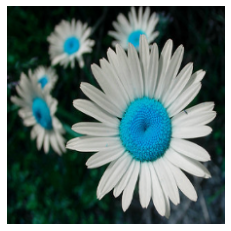

In [132]:
"""
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}
"""
print(y_test[0]) # daisy
plt.axis('off')
plt.imshow(X_test[0])


0


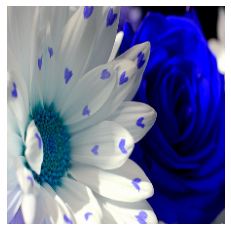

In [133]:
print(y_test[1]) # roses
plt.axis('off')
plt.imshow(X_test[1])

2


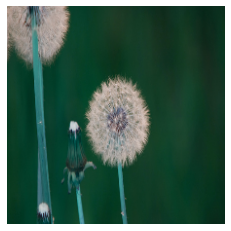

In [134]:
print(y_test[2]) # dandelion
plt.axis('off')
plt.imshow(X_test[2])

4


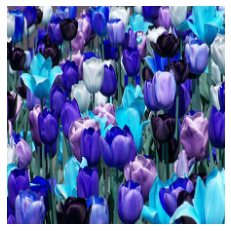

In [135]:
print(y_test[3]) # tulips
plt.axis('off')
plt.imshow(X_test[3])

2


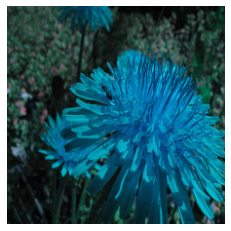

In [136]:
print(y_test[4]) # dandelion
plt.axis('off')
plt.imshow(X_test[4])

In [137]:
predicted_0 = model.predict([X_test_scaled[:5]])
predicted_0

array([[-5.148607  ,  4.183804  , -1.3705081 ,  1.3962095 , -3.1330872 ],
       [-3.1802201 ,  0.5380732 , -4.4762597 , -0.8191532 , -0.47180578],
       [-7.4463925 , -4.3426967 ,  5.5525885 , -1.1017231 , -5.380576  ],
       [-0.2627599 , -4.6894884 , -5.286173  , -2.2726245 ,  5.9961534 ],
       [-5.2719016 , -3.7688906 ,  5.397334  , -0.11881834, -3.0008948 ]],
      dtype=float32)

In [138]:
predicted_0 = np.argmax(predicted_0[:5], axis=1)
predicted_0
#Predicted Result

array([1, 1, 2, 4, 2], dtype=int64)

In [139]:
y_test[:5]
# Actual result

array([1, 0, 2, 4, 2])

### Conclusion 3: 
- Here it predicted all 4 images almost correctly 